Testing how to plot race lap times for a single driver.

In [1]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]


# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

real_laps = race.telemetry.lap_times[race.telemetry.lap_times['Lap']>0]
lap_times_table = real_laps.sort_values('Lap')
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]

lap_speeds = lap_speeds.sort_values('Lap')

# 
plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='r', alpha=0.3)
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()


# Need to 

ModuleNotFoundError: No module named 'pandas'

Plot lap-time distributions — green-flag laps cluster around one peak, pit-stop and caution laps form a long right tail

Fetching Data for 2025-1-5553


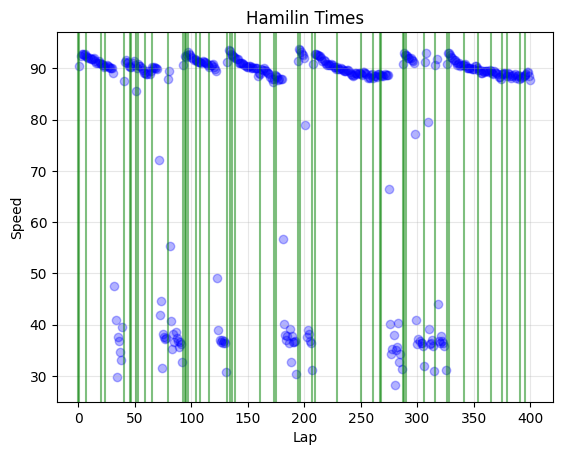

In [16]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

# Speed per lap for one racer
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]
lap_speeds = lap_speeds.sort_values('Lap')

# vline for each lap that is green lap
race.telemetry.events['Lap'] = pd.to_numeric(race.telemetry.events['Lap'], errors='coerce')
race_events = race.telemetry.events[race.telemetry.events['Lap'] > 0]
events_table_sorted = race_events.sort_values('Lap')

green_laps = race.telemetry.events.loc[
    race.telemetry.events['Flag'] == 'Green',
    ['Lap']
]


plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
for lap in green_laps['Lap']:
    plt.axvline(x=lap, color='green', alpha=0.5, linestyle='-')
plt.axvline
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()

Now adding caution laps

In [4]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

# Speed per lap for one racer
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]
lap_speeds = lap_speeds.sort_values('Lap')

# vline for each lap that is green lap
race.telemetry.events['Lap'] = pd.to_numeric(race.telemetry.events['Lap'], errors='coerce')
race_events = race.telemetry.events[race.telemetry.events['Lap'] > 0]
events_table_sorted = race_events.sort_values('Lap')

colored_laps = race.telemetry.events.loc[
    race.telemetry.events['Flag'].isin(['Green', 'Yellow']),
    ['Flag','Lap']
]

plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
# a zip pairs up multi iterables element by element 
for lap, flag in zip(colored_laps['Lap'], colored_laps['Flag']):
    if flag == 'Green':
        plt.axvline(x=lap, color='green', alpha=0.5, linestyle='-')
    elif flag == 'Yellow':
        plt.axvline(x=lap, color='gold', alpha=0.5, linestyle='-')
plt.axvline
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()

ModuleNotFoundError: No module named 'pandas'

Adding pit stops 

Fetching Data for 2025-1-5553


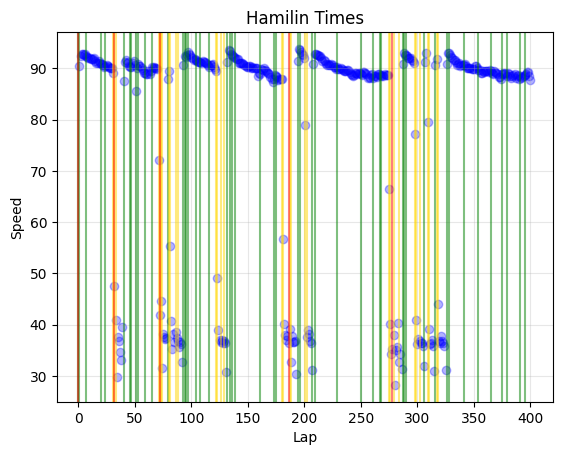

In [12]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

# Speed per lap for one racer
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]
lap_speeds = lap_speeds.sort_values('Lap')

# vline for each lap that is green lap
race.telemetry.events['Lap'] = pd.to_numeric(race.telemetry.events['Lap'], errors='coerce')
race_events = race.telemetry.events[race.telemetry.events['Lap'] > 0]
events_table_sorted = race_events.sort_values('Lap')

colored_laps = race.telemetry.events.loc[
    race.telemetry.events['Flag'].isin(['Green', 'Yellow']),
    ['Flag','Lap']
]

# pit stops ##########################################################
real_stops = race.telemetry.pit_stops[race.telemetry.pit_stops['lap']>0]
pit_stop_table = real_stops.sort_values('lap')

# race.telemetry.pit_stops - Pit stop data
#   Columns: driver_name, lap, manufacturer, pit_in_flag_status, pit_out_flag_status, pit_in_race_time, pit_out_race_time, 
# total_duration, box_stop_race_time, box_leave_race_time, pit_stop_duration, in_travel_duration, out_travel_duration, pit_stop_type,
# left_front_tire_changed, left_rear_tire_changed, right_front_tire_changed, right_rear_tire_changed, previous_lap_time, next_lap_time, 
# pit_in_rank, pit_out_rank, positions_gained_lost, driver_id, car_number

pit_stops = race.telemetry.pit_stops.loc[
    race.telemetry.pit_stops['driver_name'] == 'Denny Hamlin',
    ['lap']
]

plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
# a zip pairs up multi iterables element by element 
for lap, flag in zip(colored_laps['Lap'], colored_laps['Flag']):
    if flag == 'Green':
        plt.axvline(x=lap, color='green', alpha=0.5, linestyle='-')
    elif flag == 'Yellow':
        plt.axvline(x=lap, color='gold', alpha=0.5, linestyle='-')
for lap in pit_stops['lap']:
    plt.axvline(x=lap, color='red', alpha=0.5, linestyle='-')
plt.axvline
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()

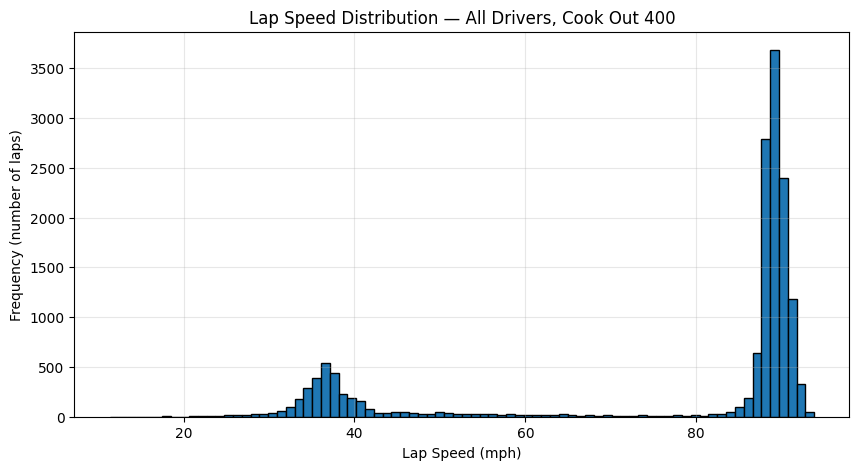

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(
    race.telemetry.lap_times.loc[race.telemetry.lap_times['lap_speed'] > 0, 'lap_speed'],
    bins=80,
    edgecolor='black'
)
plt.xlabel('Lap Speed (mph)')
plt.ylabel('Frequency (number of laps)')
plt.title('Lap Speed Distribution — All Drivers, Cook Out 400')
plt.grid(True, alpha=0.3)
plt.show()

Cleaning up Figure

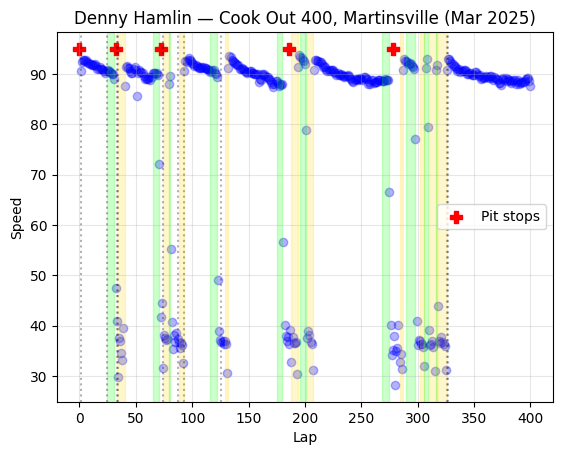

In [31]:
# Sort all flag changes by lap into a single timeline
flag_changes = colored_laps.sort_values('Lap').reset_index(drop=True)

# Walk through and shade each Yellow → Green pair

plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
# a zip pairs up multi iterables element by element 
for i in range(len(flag_changes) - 1):
    if flag_changes.iloc[i]['Flag'] == 'Yellow' and flag_changes.iloc[i+1]['Flag'] == 'Green':
        plt.axvspan(
            flag_changes.iloc[i]['Lap'],
            flag_changes.iloc[i+1]['Lap'],
            color='gold',
            alpha=0.2,
        )
    if flag_changes.iloc[i]['Flag'] == 'Green' and flag_changes.iloc[i+1]['Flag'] == 'Yellow':
        plt.axvspan(
            flag_changes.iloc[i]['Lap'],
            flag_changes.iloc[i+1]['Lap'],
            color='lime',
            alpha=0.2,
        )
# for lap in pit_stops['lap']:
#     plt.axvline(x=lap, color='red', alpha=0.5, linestyle='x')
plt.scatter(
    x=pit_stops['lap'],
    y=[95] * len(pit_stops),   # all markers at y=95 — top of your speed range
    color='red',
    marker='P',
    s=80,
    label='Pit stops'
)
for lap in race.results.lead_changes['start_lap']:
    plt.axvline(x=lap, color='black', alpha=0.3, linestyle=':')
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.legend()
plt.title('Denny Hamlin — Cook Out 400, Martinsville (Mar 2025)')
plt.grid(True, alpha=0.3)
plt.show()       
